# Two-stage ESG portfolio: full analysis (compact)
Needs `data/` with prices.csv, volume.csv, rf_irx.csv (auto-downloaded if missing), esg_kaggle.csv (Kaggle, doi:10.34740/kaggle/ds/3660201) and optionally sectors.csv. Run all cells (about 5-10 min).

In [1]:
import os, warnings
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.defaultaction = "ignore"
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, cvxpy as cp, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.covariance import LedoitWolf
D, OUT, SEED = "data/", "out/", 42
H, TOP, WMAX, COST, NT = 63, 20, 0.10, 0.001, 300
FEATS = ["mom12_1", "ret1m", "ret3m", "ret6m", "rel12", "vol60", "vol252", "lvol", "dd252", "beta252"]
ESG_START = pd.Timestamp("2023-03-31")
KS = [1.0, 0.9, 0.8, 0.7]
os.makedirs(D, exist_ok=True); os.makedirs(OUT, exist_ok=True)

In [2]:
# Data (EA delisted 2026-08-04, excluded)
TICKERS = """AAPL MSFT NVDA AMZN GOOG GOOGL META ADBE AMD MRNA ADI ALGN
AEP AMAT AMGN PANW ASML AZN TEAM ADSK ADP BKR BIIB BKNG
AVGO CDNS CDW CEG CHTR CMCSA COST CPRT CRWD CSCO CSGP CSX
CTAS CTSH DASH DDOG DXCM EXC FANG FAST FTNT GEHC GFS GILD
HON IDXX INTC INTU ISRG KDP KHC KLAC LIN LRCX LULU MAR
MCHP MDLZ MELI MNST MRVL MSTR MU NFLX NXPI ODFL ON ORLY
PAYX PCAR PDD PEP PLTR PYPL QCOM REGN ROP ROST SBUX SHOP
SNPS TMUS TSLA TTD TTWO TXN VRSK VRTX WBD WDAY XEL ZS
APP AXON CCEP""".split()
if not os.path.exists(D + "prices.csv"):
    import yfinance as yf
    x = yf.download(TICKERS + ["QQQ"], start="2017-01-01", end="2026-09-19", auto_adjust=True, progress=False)
    x["Close"].to_csv(D + "prices.csv"); x["Volume"].to_csv(D + "volume.csv")
    yf.download("^IRX", start="2017-01-01", end="2026-09-19", progress=False)["Close"].squeeze().rename("IRX_pct").to_csv(D + "rf_irx.csv")
P = pd.read_csv(D + "prices.csv", index_col=0, parse_dates=True).drop(columns=["EA"], errors="ignore")
V = pd.read_csv(D + "volume.csv", index_col=0, parse_dates=True)[P.columns]
d = P.index
rf = pd.read_csv(D + "rf_irx.csv", index_col=0, parse_dates=True)["IRX_pct"].reindex(d).ffill() / 100 / 252
Q, Rq = P["QQQ"], P["QQQ"].pct_change()
STOCKS = [c for c in P.columns if c != "QQQ"]
print(len(d), "days", d[0].date(), "->", d[-1].date(), "|", len(STOCKS), "stocks")

2441 days 2017-01-03 -> 2026-09-18 | 99 stocks


In [3]:
# Stage 1: Random Forest
def setup(stocks):
    global S, R, ok, RK, y
    S, VS = P[stocks], V[stocks]; R = S.pct_change()
    F = {"mom12_1": S.shift(21) / S.shift(252) - 1, "ret1m": S / S.shift(21) - 1, "ret3m": S / S.shift(63) - 1,
         "ret6m": S / S.shift(126) - 1, "rel12": (S / S.shift(252) - 1).sub(Q / Q.shift(252) - 1, axis=0),
         "vol60": R.rolling(60).std(), "vol252": R.rolling(252).std(), "lvol": np.log(VS.rolling(60).mean()),
         "dd252": S / S.rolling(252).max() - 1, "beta252": R.rolling(252).cov(Rq).div(Rq.rolling(252).var(), axis=0)}
    ok = S.notna() & S.shift(252).notna() & (VS.rolling(60).mean() > 1e6) & (F["vol60"] < 0.05)
    for f in F.values(): ok &= f.notna()
    RK = {k: f.where(ok).rank(axis=1, pct=True) for k, f in F.items()}
    fwd = S.shift(-H) / S - 1
    y = (fwd.sub(Q.shift(-H) / Q - 1, axis=0) > 0).astype(float).where(fwd.notna())

def formation():
    qe = pd.DatetimeIndex(pd.Series(d, index=d).groupby([d.year, d.quarter]).last().values)
    return [d.get_loc(t) for t in qe if pd.Timestamp("2019-12-31") <= t < d[-1]]

def sample(j):
    o = ok.iloc[j]; t = o.index[o.values]
    return t, np.column_stack([RK[k].iloc[j][t].values for k in FEATS]), y.iloc[j][t].values

def probs_at(i):
    t, Xn, _ = sample(i); Xs, ys = [], []
    for j in range(252, i - H + 1, 21):
        _, X, yj = sample(j); m = ~np.isnan(yj)
        if m.sum(): Xs.append(X[m]); ys.append(yj[m])
    m = RandomForestClassifier(n_estimators=NT, max_depth=5, min_samples_leaf=30, max_features="sqrt", random_state=SEED, n_jobs=-1)
    m.fit(np.vstack(Xs), np.concatenate(ys))
    return pd.Series(m.predict_proba(Xn)[:, list(m.classes_).index(1.0)], index=t)

setup(STOCKS); FI = formation()
probs = {i: probs_at(i) for i in FI + [len(d) - 1]}

In [4]:
# Stage 2: minimum variance optimisation
def mv(win, esg=None, cap=None, sign=1):
    n = win.shape[1]; Sg = LedoitWolf().fit(win.values).covariance_; mu = win.mean().values
    x = cp.Variable(n); c = [cp.sum(x) == 1, x >= 0, x <= max(WMAX, 1 / n + 1e-6), mu @ x >= mu.mean()]
    if esg is not None:
        if sign > 0:
            lo = cp.Problem(cp.Minimize(esg @ x), c); lo.solve(solver=cp.CLARABEL)
            c.append(esg @ x <= max(cap, lo.value + 1e-4))
        else:
            c.append(esg @ x >= cap)
    cp.Problem(cp.Minimize(cp.quad_form(x, cp.psd_wrap(Sg))), c).solve(solver=cp.CLARABEL)
    w = np.clip(x.value, 0, None); return w / w.sum()

def weights(i, names, mode="MV", k=1.0, e=None):
    win = R.iloc[i - 251:i + 1][names].dropna(axis=1, how="any"); nm = list(win.columns)
    if mode == "EW": return pd.Series(1 / len(nm), index=nm)
    if mode == "MV": return pd.Series(mv(win), index=nm)
    ev = (E if e is None else e).reindex(nm)
    return pd.Series(mv(win, ev.values, ev.mean() * k, 1 if mode == "ESG" else -1), index=nm)

In [5]:
# Simulation and metrics
def sim(wl):
    r = pd.Series(np.nan, index=d); tv, prev = [], None
    for n, (i, w) in enumerate(wl):
        j = wl[n + 1][0] if n + 1 < len(wl) else len(d) - 1
        if i >= j: continue
        g = (1 + R.iloc[i + 1:j + 1][w.index].fillna(0)).cumprod(); v = (g * w.values).sum(axis=1)
        x = v.pct_change(); x.iloc[0] = v.iloc[0] - 1
        u = w.index if prev is None else w.index.union(prev.index)
        t = w.abs().sum() if prev is None else (w.reindex(u).fillna(0) - prev.reindex(u).fillna(0)).abs().sum()
        tv.append(t); x.iloc[0] -= COST * t; r.iloc[i + 1:j + 1] = x.values
        prev = pd.Series(g.iloc[-1].values * w.values / v.iloc[-1], index=w.index)
    return r, (np.mean(tv[1:]) if len(tv) > 1 else np.nan)

def stats(r, turn=np.nan, esg=np.nan):
    r = r.dropna(); ex = r - rf.reindex(r.index); w = (1 + r).cumprod()
    return dict(Return=(1 + r).prod() ** (252 / len(r)) - 1, Vol=r.std() * 252 ** .5, Sharpe=ex.mean() / r.std() * 252 ** .5,
                Sortino=ex.mean() / np.sqrt((np.minimum(ex, 0) ** 2).mean()) * 252 ** .5, MaxDD=(w / w.cummax() - 1).min(),
                Turnover=turn, ESGrisk=esg)

def boot(Rt, pairs, B=5000, L=21):
    X = Rt.dropna(); X = X.sub(rf.reindex(X.index), axis=0); T = len(X); rng = np.random.default_rng(0)
    sh = lambda a: a.mean(0) / a.std(0, ddof=1) * 252 ** .5
    draw = lambda: ((rng.integers(0, T, int(np.ceil(T / L)))[:, None] + np.arange(L)) % T).ravel()[:T]
    out = []
    for a, b in pairs:
        xa, xb = X[a].values, X[b].values; obs = sh(xa) - sh(xb)
        dd = np.array([sh(xa[j]) - sh(xb[j]) for j in (draw() for _ in range(B))])
        out.append(dict(A=a, B=b, dSharpe=obs, lo=np.percentile(dd, 2.5), hi=np.percentile(dd, 97.5), p=(np.abs(dd - dd.mean()) >= abs(obs)).mean()))
    return pd.DataFrame(out)

In [6]:
# Backtest without ESG
def strategies(pr, n_rand=30):
    rng = np.random.default_rng(SEED); pk = {"all": [], "rf": [], "mom": []}; rp = [[] for _ in range(n_rand)]
    for i in FI:
        p = pr[i]; nm = list(p.index)
        pk["all"].append((i, nm)); pk["rf"].append((i, p.sort_values(ascending=False).head(TOP).index.tolist()))
        pk["mom"].append((i, RK["mom12_1"].iloc[i][nm].sort_values(ascending=False).head(TOP).index.tolist()))
        for r in range(n_rand): rp[r].append((i, list(rng.choice(nm, size=min(TOP, len(nm)), replace=False))))
    go = lambda L, m: sim([(i, weights(i, n, m)) for i, n in L])
    st = {"EW-Universe": go(pk["all"], "EW"), "MV-Universe": go(pk["all"], "MV"), "EW-RF20": go(pk["rf"], "EW"),
          "MV-RF20 (proposed)": go(pk["rf"], "MV"), "MV-Momentum20": go(pk["mom"], "MV")}
    rnd = pd.DataFrame([stats(*go(L, "MV")) for L in rp])
    q = Rq.copy(); q[q.index < d[FI[0] + 1]] = np.nan; st["QQQ"] = (q, 0.0)
    tab = pd.DataFrame({k: stats(*v) for k, v in st.items()}).T
    tab.loc[f"MV-Random20 (mean of {n_rand})"] = rnd.mean(); tab.loc[f"MV-Random20 (sd of {n_rand})"] = rnd.std()
    return tab, pd.DataFrame({k: v[0] for k, v in st.items()})

tab, rets = strategies(probs)
print("Full out-of-sample period:", d[FI[0] + 1].date(), "->", d[-1].date(), "|", len(FI), "rebalances"); print(tab.round(3).to_string())
w0, w1 = pd.Timestamp("2024-10-25"), pd.Timestamp("2025-10-24")
print("\nPaper window:"); print(pd.DataFrame({k: stats(rets[k].loc[w0:w1]) for k in rets}).T.round(3).to_string())
pairs = [("MV-RF20 (proposed)", "QQQ"), ("MV-RF20 (proposed)", "EW-Universe"), ("MV-RF20 (proposed)", "MV-Universe"),
         ("MV-RF20 (proposed)", "MV-Momentum20"), ("EW-RF20", "EW-Universe"), ("EW-RF20", "QQQ")]
tests = boot(rets, pairs); print("\nSharpe-difference tests:"); print(tests.round(3).to_string())
tab.to_csv(OUT + "main_metrics.csv"); rets.to_csv(OUT + "main_returns.csv"); tests.to_csv(OUT + "main_tests.csv", index=False)

Full out-of-sample period: 2020-01-02 -> 2026-09-18 | 27 rebalances
                          Return    Vol  Sharpe  Sortino  MaxDD  Turnover  ESGrisk
EW-Universe                0.218  0.229   0.853    1.217 -0.308     0.220      NaN
MV-Universe                0.162  0.169   0.805    1.137 -0.308     0.642      NaN
EW-RF20                    0.356  0.321   1.022    1.496 -0.467     1.138      NaN
MV-RF20 (proposed)         0.318  0.287   1.008    1.484 -0.362     1.476      NaN
MV-Momentum20              0.278  0.263   0.958    1.365 -0.342     1.120      NaN
QQQ                        0.207  0.249   0.768    1.094 -0.351     0.000      NaN
MV-Random20 (mean of 30)   0.163  0.200   0.712    1.011 -0.323     1.635      NaN
MV-Random20 (sd of 30)     0.037  0.005   0.160    0.234  0.023     0.034      NaN

Paper window:
                    Return    Vol  Sharpe  Sortino  MaxDD  Turnover  ESGrisk
EW-Universe          0.202  0.214   0.771    1.149 -0.209       NaN      NaN
MV-Universe     

In [7]:
# Random Forest AUC
from sklearn.metrics import roc_auc_score
o = pd.concat([pd.DataFrame({"d": d[i], "p": p.values, "y": y.iloc[i][p.index].values}) for i, p in probs.items()]).dropna()
q_auc = o.groupby("d").apply(lambda g: roc_auc_score(g.y, g.p) if g.y.nunique() > 1 else np.nan)
print(f"pooled AUC {roc_auc_score(o.y, o.p):.3f} | mean quarterly AUC {q_auc.mean():.3f} | share of quarters > 0.5: {(q_auc > 0.5).mean():.0%}")

pooled AUC 0.510 | mean quarterly AUC 0.526 | share of quarters > 0.5: 69%


In [8]:
# Table 1
ann_ret = S.iloc[-1] / S.iloc[-253] - 1
ann_vol = R.iloc[-252:].std() * np.sqrt(252)
avg_vol60 = V[STOCKS].rolling(60).mean().iloc[-1] / 1e6
sec_map = pd.read_csv(D + "sectors.csv", index_col=0)["Sector"] if os.path.exists(D + "sectors.csv") else pd.Series(index=STOCKS, dtype=object)

table1 = pd.DataFrame({
    "Rank": range(1, len(STOCKS) + 1),
    "Symbol": STOCKS,
    "Sector": sec_map.reindex(STOCKS).values,
    "Annual Return": (ann_ret.reindex(STOCKS) * 100).round(2).astype(str) + "%",
    "Volatility": (ann_vol.reindex(STOCKS) * 100).round(2).astype(str) + "%",
    "Average Volume (in millions)": avg_vol60.reindex(STOCKS).round(2).values,
})
table1.to_csv(OUT + "table1_universe.csv", index=False)
table1

,Rank,Symbol,Sector,Annual Return,Volatility,Average Volume (in millions)
AAPL,1,AAPL,NaN,41.17%,25.0%,53.62
ADBE,2,ADBE,NaN,-31.25%,40.58%,5.45
ADI,3,ADI,NaN,54.44%,36.12%,4.06
ADP,4,ADP,NaN,-3.34%,27.42%,2.43
ADSK,5,ADSK,NaN,-32.05%,37.94%,2.29
...,...,...,...,...,...,...
VRTX,95,VRTX,NaN,31.3%,28.72%,1.42
WBD,96,WBD,NaN,54.53%,26.0%,20.78
WDAY,97,WDAY,NaN,-17.46%,54.07%,4.47
XEL,98,XEL,NaN,3.46%,19.92%,5.29


In [9]:
# Table 2
i = len(d) - 1
p_today = probs[i]
top20 = p_today.sort_values(ascending=False).head(TOP)
ann_ret20 = S.iloc[-1] / S.iloc[-253] - 1
ann_vol20 = R.iloc[-252:].std() * np.sqrt(252)
avgvol20 = V[STOCKS].rolling(60).mean().iloc[-1]

table2 = pd.DataFrame({
    "Rank": range(1, 21),
    "Symbol": top20.index,
    "Annual Return": (ann_ret20.reindex(top20.index) * 100).round(2).astype(str) + "%",
    "Volatility": (ann_vol20.reindex(top20.index) * 100).round(2).astype(str) + "%",
    "Average Volume (in millions)": (avgvol20.reindex(top20.index) / 1e6).round(2).values,
    "RF probability": top20.round(3).values,
})
table2.to_csv(OUT + "table2_top20.csv", index=False)
table2

,Rank,Symbol,Annual Return,Volatility,Average Volume (in millions),RF probability
AMD,1,AMD,251.73%,72.1%,24.82,0.616
INTC,2,INTC,336.14%,80.0%,108.08,0.610
NVDA,3,NVDA,30.84%,38.08%,128.64,0.572
QCOM,4,QCOM,9.78%,53.03%,13.93,0.551
KLAC,5,KLAC,79.77%,60.67%,11.66,0.548
AMAT,6,AMAT,150.96%,60.13%,8.54,0.548
TSLA,7,TSLA,-14.46%,46.37%,39.54,0.539
AVGO,8,AVGO,4.06%,46.36%,23.09,0.536
NXPI,9,NXPI,4.56%,49.48%,3.88,0.535
SHOP,10,SHOP,-13.1%,58.5%,8.99,0.532


In [10]:
# ESG data
E = pd.read_csv(D + "esg_kaggle.csv").set_index("Symbol")["Total ESG Risk score"].dropna()
E["GOOG"] = E["GOOGL"]
E = E.reindex(STOCKS).dropna()
print(f"ESG coverage: {len(E)} of {len(STOCKS)} | missing: {sorted(set(STOCKS) - set(E.index))}")
prev = pd.Series({"XEL": 26.81, "CSCO": 10.19, "MNST": 28.92, "GILD": 20.69, "NFLX": 12.12})
print(pd.DataFrame({"snapshot_2023": E.reindex(prev.index), "paper_2025": prev}).round(2).T.to_string())

ESG coverage: 68 of 99 | missing: ['ALGN', 'AMD', 'APP', 'ASML', 'AXON', 'AZN', 'BKR', 'CCEP', 'CEG', 'CRWD', 'DASH', 'DDOG', 'FANG', 'GEHC', 'GFS', 'KDP', 'LIN', 'MELI', 'MRNA', 'MRVL', 'MSTR', 'ODFL', 'PDD', 'PLTR', 'SHOP', 'TEAM', 'TTD', 'TTWO', 'WBD', 'WDAY', 'ZS']
                 XEL   CSCO   MNST   GILD   NFLX
snapshot_2023  26.50  13.90  29.20  23.00  16.40
paper_2025     26.81  10.19  28.92  20.69  12.12


In [11]:
# ESG strategies
def pick(i, kind):
    p = probs[i]; el = [s for s in p.index if s in E.index]; pe = p[el].sort_values(ascending=False)
    if kind == "all": return el
    if kind == "rf": return pe.head(TOP).index.tolist()
    if kind == "low": return E[el].sort_values().head(TOP).index.tolist()
    keep = E[el].sort_values().head(int(round(len(el) * .75))).index
    return pe[[s for s in pe.index if s in keep]].head(TOP).index.tolist()

SPEC = {"EW-Universe": ("all", "EW", 1), "MV-Universe": ("all", "MV", 1), "EW-RF20": ("rf", "EW", 1), "MV-RF20 (no ESG)": ("rf", "MV", 1),
        **{f"MV-RF20 + ESG x{k}": ("rf", "ESG", k) for k in KS}, "MV-RF20 + ESG (orig. wrong direction)": ("rf", "ESGwrong", 1.0),
        "MV-RF20 on ESG-screened universe": ("scr", "MV", 1), "MV-LowestESG20 (no ML)": ("low", "MV", 1)}
W = {n: [(i, weights(i, pick(i, kd), m, k)) for i in FI] for n, (kd, m, k) in SPEC.items()}

def esg_run(start):
    idx = {i for i in FI if d[i] >= start}; res, rt = {}, {}
    for n, wl in W.items():
        sub = [(i, w) for i, w in wl if i in idx]; r, t = sim(sub)
        res[n] = stats(r, t, np.mean([(w * E.reindex(w.index)).sum() / w.sum() for _, w in sub])); rt[n] = r
    q = Rq.copy(); q[q.index < d[min(idx) + 1]] = np.nan; res["QQQ"] = stats(q, 0.0); rt["QQQ"] = q
    return pd.DataFrame(res).T, pd.DataFrame(rt), len(idx)

te, re_, n1 = esg_run(ESG_START)
print(f"MAIN ESG WINDOW (no look-ahead): {n1} rebalances"); print(te.round(3).to_string())
tf, _, n2 = esg_run(pd.Timestamp("2019-12-31"))
print(f"\nSENSITIVITY, ESG snapshot applied to all dates (look-ahead): {n2} rebalances"); print(tf.round(3).to_string())
tt = boot(re_, [("MV-RF20 + ESG x1.0", "MV-RF20 (no ESG)"), ("MV-RF20 + ESG x0.8", "MV-RF20 (no ESG)"), ("MV-RF20 + ESG x0.8", "QQQ"),
                ("MV-RF20 (no ESG)", "QQQ"), ("MV-RF20 + ESG x1.0", "QQQ"), ("MV-RF20 + ESG x0.8", "EW-Universe"), ("MV-RF20 (no ESG)", "EW-Universe")])
print("\nSharpe-difference tests (ESG window):"); print(tt.round(3).to_string())
te.to_csv(OUT + "esg_metrics.csv"); tf.to_csv(OUT + "esg_metrics_fullwindow.csv"); re_.to_csv(OUT + "esg_returns.csv"); tt.to_csv(OUT + "esg_tests.csv", index=False)

MAIN ESG WINDOW (no look-ahead): 14 rebalances
                                       Return    Vol  Sharpe  Sortino  MaxDD  Turnover  ESGrisk
EW-Universe                             0.205  0.163   0.951    1.413 -0.185     0.156   20.549
MV-Universe                             0.148  0.114   0.876    1.293 -0.092     0.568   21.736
EW-RF20                                 0.337  0.248   1.115    1.659 -0.264     0.825   19.360
MV-RF20 (no ESG)                        0.299  0.200   1.183    1.763 -0.222     1.196   19.466
MV-RF20 + ESG x1.0                      0.290  0.201   1.145    1.698 -0.222     1.195   19.182
MV-RF20 + ESG x0.9                      0.306  0.209   1.169    1.728 -0.227     1.136   17.424
MV-RF20 + ESG x0.8                      0.408  0.249   1.323    1.951 -0.245     0.917   15.681
MV-RF20 + ESG x0.7                      0.438  0.269   1.320    1.962 -0.256     0.836   15.404
MV-RF20 + ESG (orig. wrong direction)   0.298  0.200   1.178    1.757 -0.222     1.185   

In [12]:
# ESG noise robustness
idx = [i for i in FI if d[i] >= ESG_START]; sel = {i: pick(i, "rf") for i in idx}; nz = []
for s in range(20):
    En = (E + np.random.default_rng(1000 + s).normal(0, 2.5, len(E))).clip(lower=0)
    wl = [(i, weights(i, sel[i], "ESG", 0.8, En)) for i in idx]; r, t = sim(wl)
    nz.append(stats(r, t, np.mean([(w * E.reindex(w.index)).sum() / w.sum() for _, w in wl])))
nz = pd.DataFrame(nz); print("Noisy-ESG robustness (20 draws):"); print(nz[["Sharpe", "Return", "Vol", "ESGrisk"]].describe().loc[["mean", "std", "min", "max"]].round(3).to_string())

Noisy-ESG robustness (20 draws):
      Sharpe  Return    Vol  ESGrisk
mean   1.238   0.367  0.239   16.305
std    0.107   0.039  0.009    0.236
min    1.082   0.299  0.221   15.855
max    1.471   0.452  0.251   16.719


In [13]:
# Final portfolio
i = len(d) - 1; p = probs[i]; sel_ = pick(i, "rf")
fin = pd.DataFrame({"RF_prob": p[sel_], "ESG_risk": E[sel_]})
for n, (m, k) in {"w_noESG": ("MV", 1.0), "w_ESGx1.0": ("ESG", 1.0), "w_ESGx0.8": ("ESG", 0.8)}.items(): fin[n] = weights(i, sel_, m, k).reindex(sel_).fillna(0)
if os.path.exists(D + "sectors.csv"): fin.insert(0, "Sector", pd.read_csv(D + "sectors.csv", index_col=0)["Sector"].reindex(sel_))
fin = fin.sort_values("w_ESGx1.0", ascending=False); print("Portfolio date:", d[i].date()); print(fin.round(3).to_string())
for c in ["w_noESG", "w_ESGx1.0", "w_ESGx0.8"]: print(f"{c}: weighted ESG risk {(fin[c] * fin.ESG_risk).sum() / fin[c].sum():.2f}")
fin.to_csv(OUT + "final_portfolio.csv")

Portfolio date: 2026-09-18
       RF_prob  ESG_risk  w_noESG  w_ESGx1.0  w_ESGx0.8
AAPL     0.522      17.2    0.100      0.100      0.100
HON      0.517      28.6    0.100      0.100      0.000
NVDA     0.572      13.6    0.100      0.100      0.100
GOOG     0.502      24.2    0.100      0.100      0.005
GOOGL    0.499      24.2    0.100      0.100      0.009
AMAT     0.548      12.7    0.100      0.100      0.100
INTU     0.508      16.4    0.096      0.100      0.100
BKNG     0.502      19.2    0.090      0.090      0.100
CHTR     0.524      24.7    0.095      0.084      0.000
INTC     0.610      18.9    0.064      0.061      0.066
PYPL     0.514      17.8    0.033      0.038      0.100
QCOM     0.551      15.4    0.006      0.016      0.100
NXPI     0.535      19.8    0.017      0.011      0.000
CDNS     0.528      12.0    0.000      0.000      0.100
SNPS     0.508      14.4    0.000      0.000      0.092
AVGO     0.536      20.0    0.000      0.000      0.000
KLAC     0.548      1

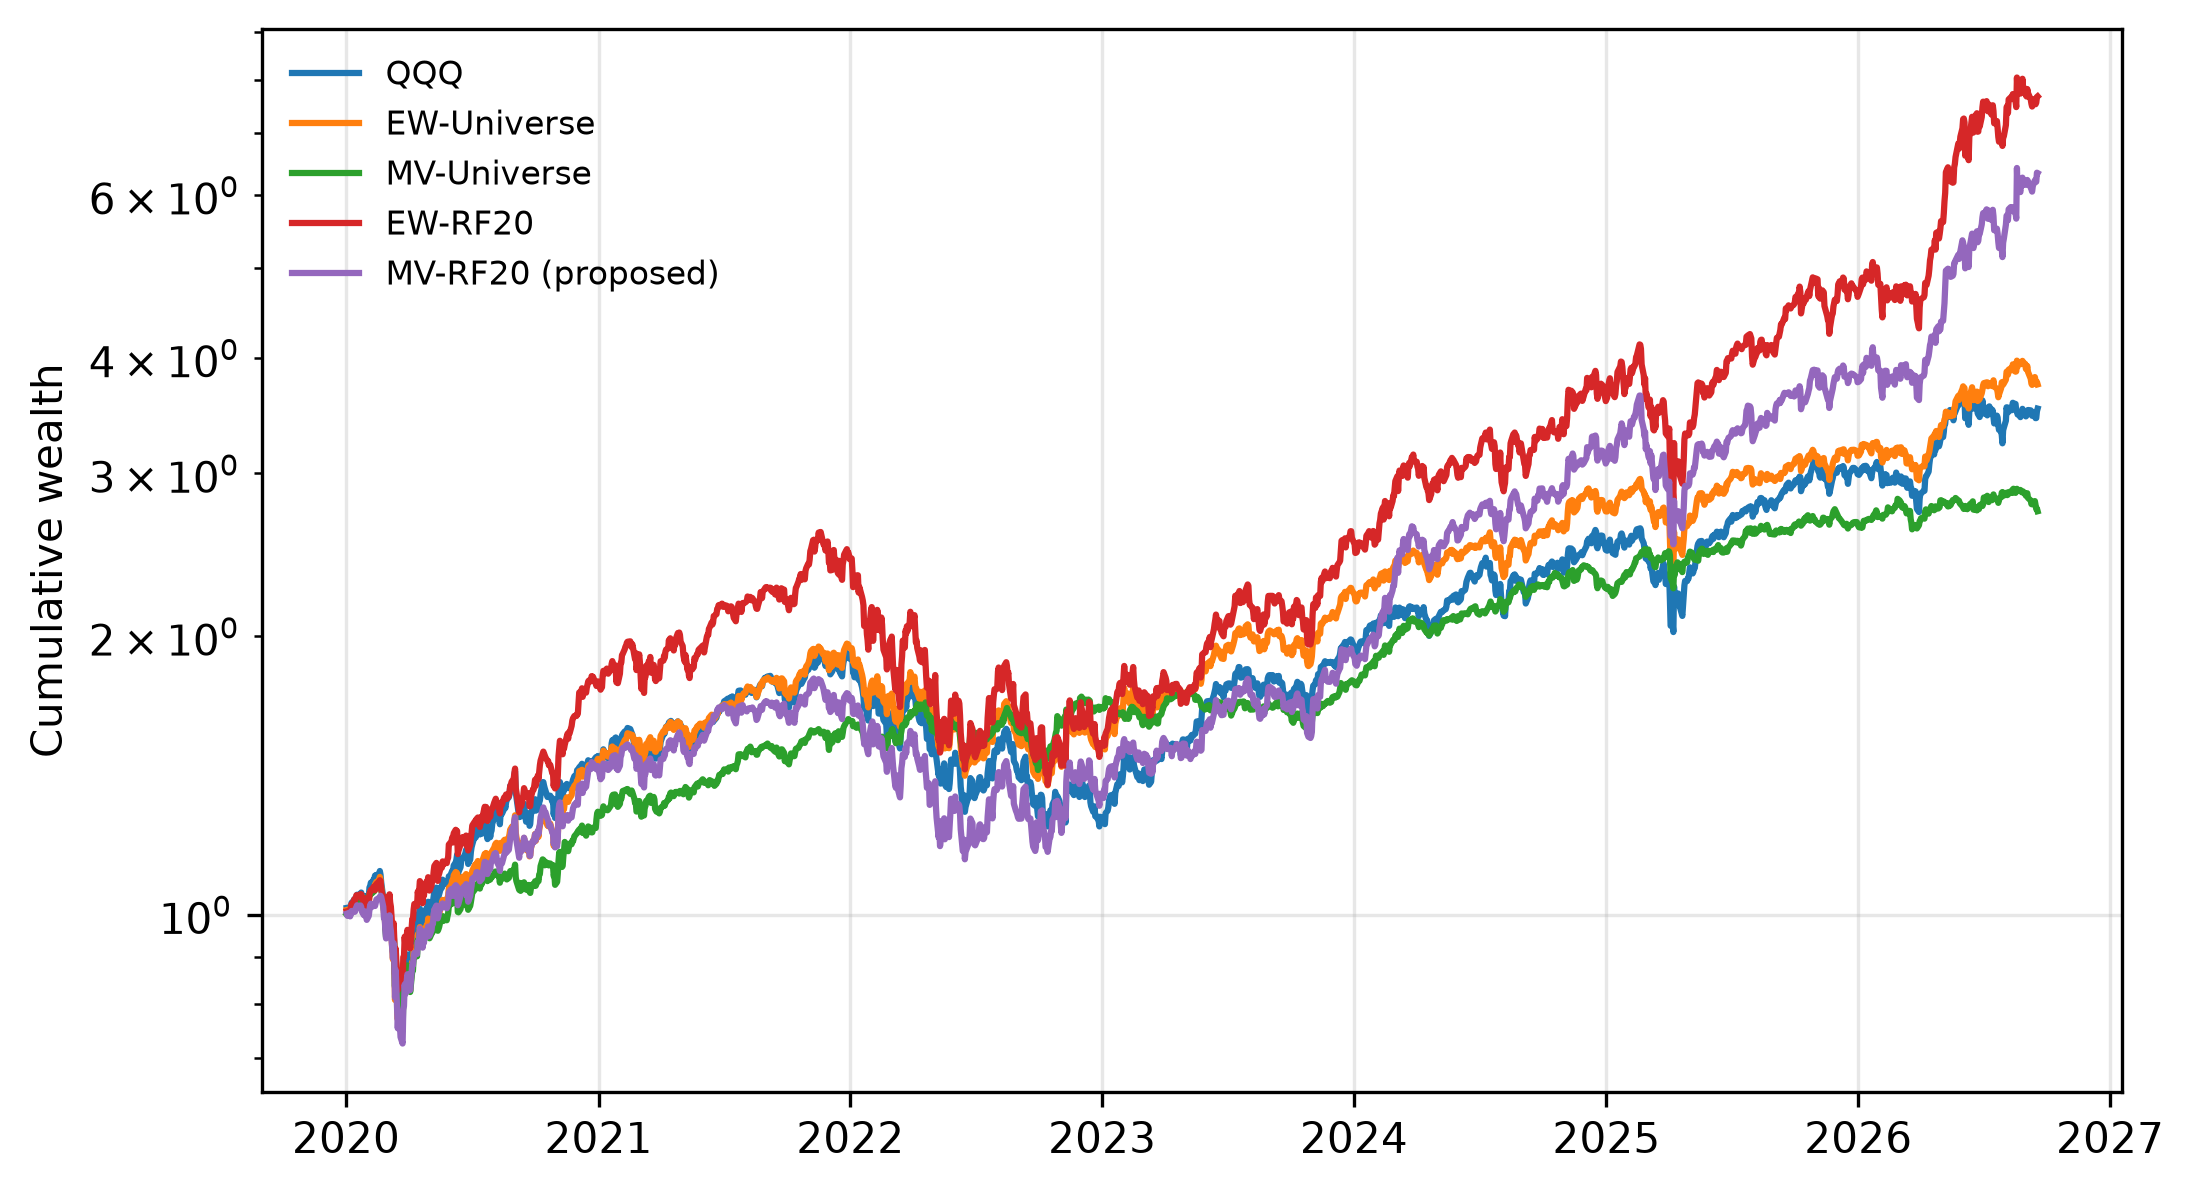

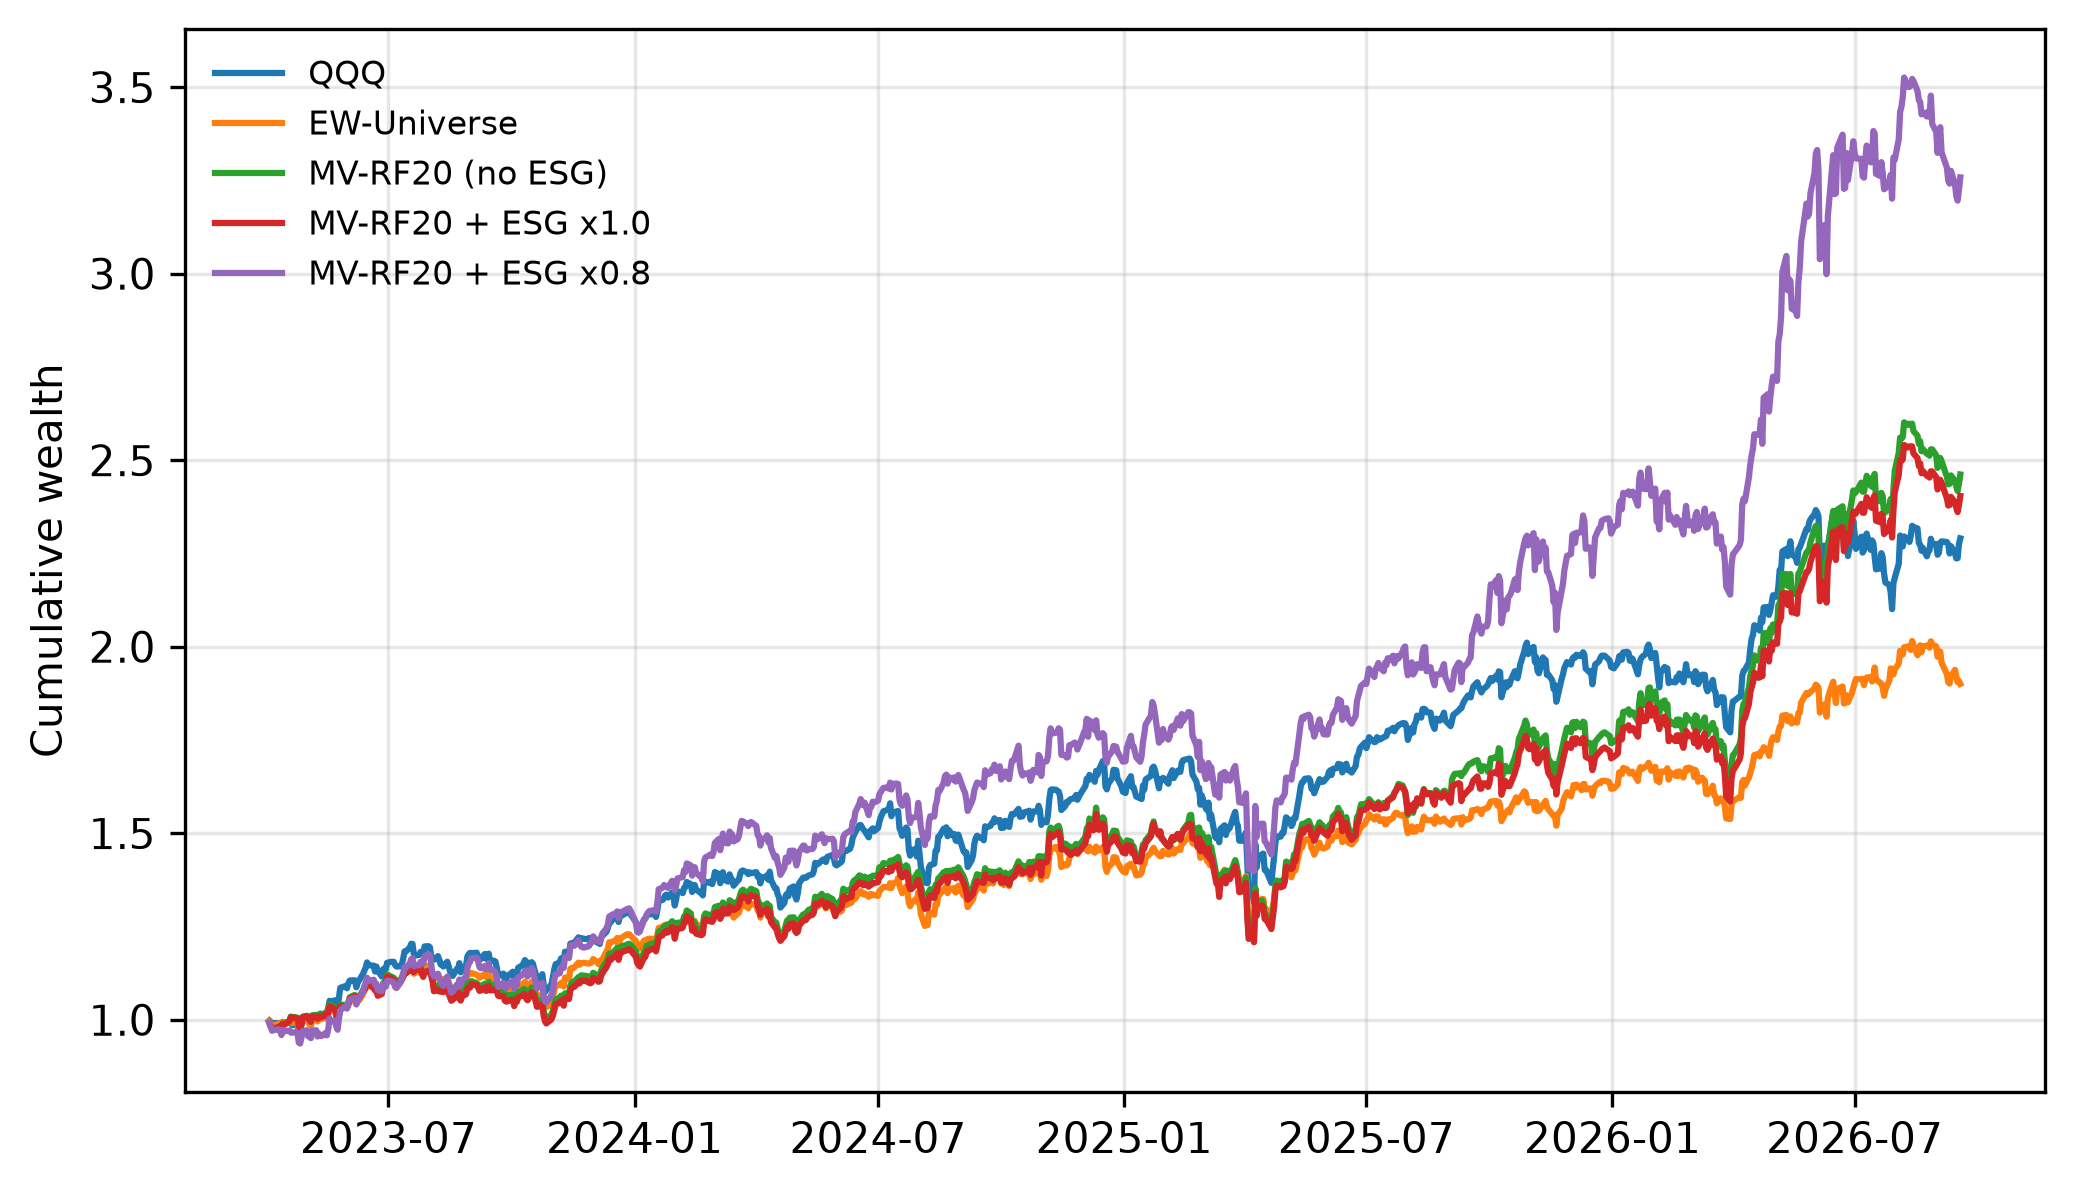

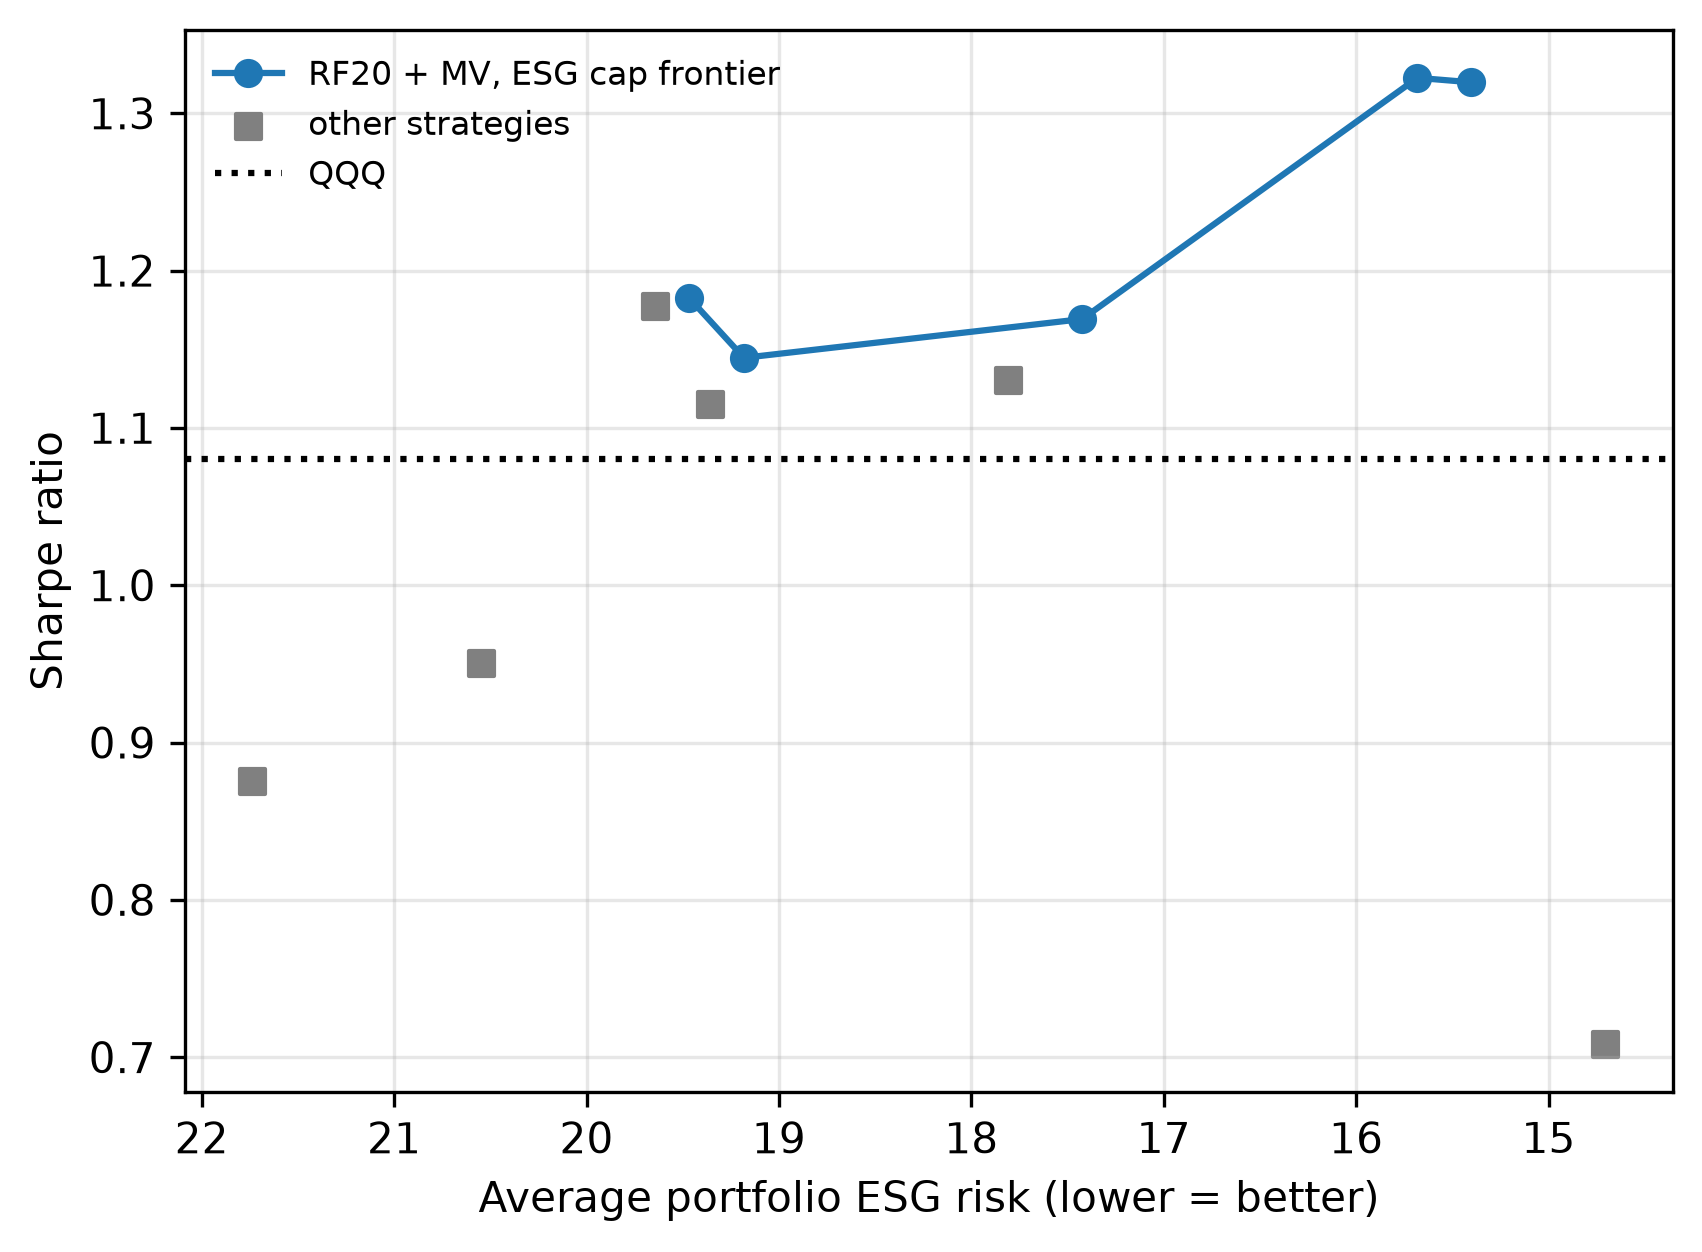

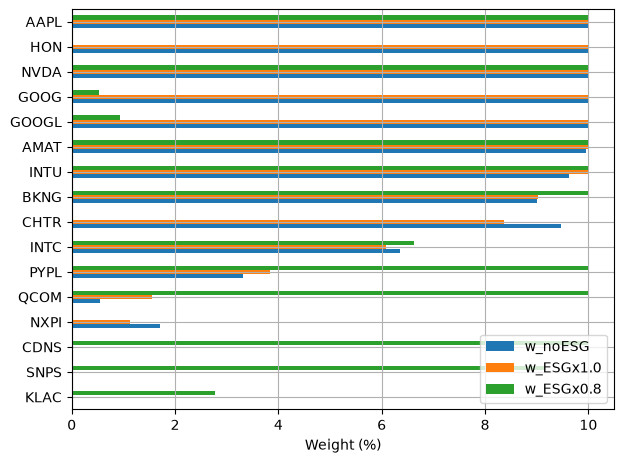

In [14]:
# Figures
def wealth(Rt, cols, fn, log=False):
    Rt = Rt.dropna(); ax = plt.figure(figsize=(8, 4.6), dpi=300).gca()
    for c in cols: ax.plot(Rt.index, (1 + Rt[c]).cumprod(), label=c)
    ax.set_yscale("log" if log else "linear"); ax.grid(alpha=.3); ax.legend(frameon=False, fontsize=8); ax.set_ylabel("Cumulative wealth")
    plt.savefig(OUT + fn, dpi=300, bbox_inches="tight"); plt.show()
wealth(rets, ["QQQ", "EW-Universe", "MV-Universe", "EW-RF20", "MV-RF20 (proposed)"], "fig_wealth_main.jpg", log=True)
wealth(re_, ["QQQ", "EW-Universe", "MV-RF20 (no ESG)", "MV-RF20 + ESG x1.0", "MV-RF20 + ESG x0.8"], "fig_wealth_esg.jpg")
fr = ["MV-RF20 (no ESG)"] + [f"MV-RF20 + ESG x{k}" for k in KS]; ax = plt.figure(figsize=(6.4, 4.6), dpi=300).gca()
ax.plot(te.loc[fr, "ESGrisk"], te.loc[fr, "Sharpe"], "-o", label="RF20 + MV, ESG cap frontier")
ax.scatter(te.drop(fr + ["QQQ"])["ESGrisk"], te.drop(fr + ["QQQ"])["Sharpe"], marker="s", color="gray", label="other strategies")
ax.axhline(te.loc["QQQ", "Sharpe"], color="k", ls=":", label="QQQ"); ax.invert_xaxis(); ax.grid(alpha=.3); ax.legend(frameon=False, fontsize=8)
ax.set_xlabel("Average portfolio ESG risk (lower = better)"); ax.set_ylabel("Sharpe ratio"); plt.savefig(OUT + "fig_esg_frontier.jpg", dpi=300, bbox_inches="tight"); plt.show()
ax = fin[fin[["w_noESG", "w_ESGx1.0", "w_ESGx0.8"]].max(axis=1) > .005][::-1][["w_noESG", "w_ESGx1.0", "w_ESGx0.8"]].mul(100).plot.barh(figsize=(7, 5.2), grid=True)
ax.set_xlabel("Weight (%)"); plt.savefig(OUT + "fig_weights.jpg", dpi=300, bbox_inches="tight"); plt.show()

In [15]:
# Robustness checks
RUN_ROBUSTNESS = True
if RUN_ROBUSTNESS:
    B0 = dict(TOP=20, WMAX=.10, H=63, NT=150, FEATS=FEATS, STOCKS=STOCKS)
    VAR = {"base_150trees": {}, "paper_features": dict(FEATS=["rel12", "vol252", "lvol"]),
           "older_constituents": dict(STOCKS=[s for s in STOCKS if P[s].first_valid_index() <= pd.Timestamp("2018-01-31")]),
           "top10": dict(TOP=10), "top30": dict(TOP=30), "wmax5%": dict(WMAX=.05), "wmax20%": dict(WMAX=.20), "horizon21": dict(H=21)}
    rob = {}
    for k, kw in VAR.items():
        globals().update({**B0, **kw}); setup(STOCKS); FI = formation(); t, _ = strategies({i: probs_at(i) for i in FI}, n_rand=10)
        rob[k] = t.loc[["MV-RF20 (proposed)", "EW-RF20", "MV-Momentum20", "EW-Universe", "MV-Universe", "QQQ"], "Sharpe"]; print("done", k, flush=True)
    rob = pd.DataFrame(rob).T; print(rob.round(3).to_string()); rob.to_csv(OUT + "robustness_sharpe.csv")

done base_150trees
done paper_features
done older_constituents
done top10
done top30
done wmax5%
done wmax20%
done horizon21
                    MV-RF20 (proposed)  EW-RF20  MV-Momentum20  EW-Universe  MV-Universe    QQQ
base_150trees                    0.838    0.964          0.958        0.853        0.805  0.768
paper_features                   1.015    1.102          0.958        0.853        0.805  0.768
older_constituents               0.839    0.914          0.754        0.786        0.711  0.768
top10                            0.970    0.970          0.983        0.853        0.805  0.768
top30                            0.913    0.945          0.958        0.853        0.805  0.768
wmax5%                           0.964    0.964          0.862        0.853        0.868  0.768
wmax20%                          0.762    0.964          0.894        0.853        0.737  0.768
horizon21                        0.977    0.951          0.958        0.853        0.805  0.768
